In [1]:
import numpy as np
import modules.tools as tools
import modules.models as models

from numpy import cos, sin, pi, exp, sqrt, sinh
import scipy.integrate as integrate
from numpy.linalg import norm

from scipy.special import erf, erfi

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


In [3]:
from functools import partial

In [4]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [6]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

## Unstrained system

In [55]:
mu = 0.0
gamma0 = 2.58
gamma1 = 0.34
gamma2 = 0.0
gamma3 = 0.17
gamma4 = 0.04

### (a) Bulk

#### Bands along hight-symmetry lines

In [8]:
params = dict(mu=mu, gamma0=gamma0, gamma1=gamma1, gamma2=gamma2, gamma3=gamma3, gamma4=gamma4)

#kz = pi # crossing point one
#kz =  -2.048# crossing point two
kz = 0.

a=1.

Mx = 2*pi/(3*a)
My = 0.
Mz = kz
    
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)
Kz = kz

k_points = [(0,0,kz), (Mx,My,Mz), (Kx,Ky,Kz), (0,0,kz)]
k_labels = ['$\Gamma$', '$M$', '$K$', '$\Gamma$']

In [9]:
ks, energies, evecs = tools.compute_bands_3D(models.H0_rhombo_graphite, params, k_points, Nk=100)

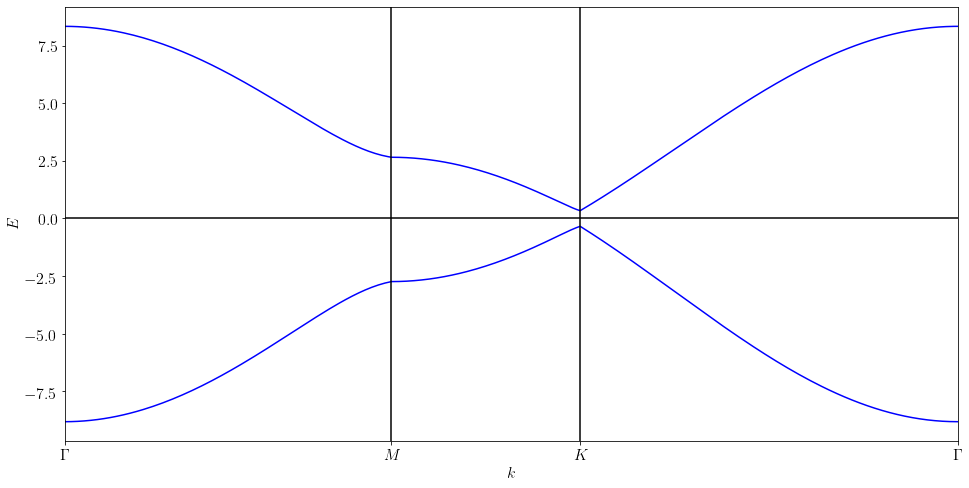

In [10]:
tools.plot_bands_3D(ks, energies, k_labels)

#### Plot several $k_z$ cuts parallel to M-K-Gamma

In [11]:
Ncuts = 21
kzs = np.linspace(-pi, 0, Ncuts, endpoint=True) 
print(kzs)

[-3.14159265 -2.98451302 -2.82743339 -2.67035376 -2.51327412 -2.35619449
 -2.19911486 -2.04203522 -1.88495559 -1.72787596 -1.57079633 -1.41371669
 -1.25663706 -1.09955743 -0.9424778  -0.78539816 -0.62831853 -0.4712389
 -0.31415927 -0.15707963  0.        ]


In [13]:
klines = []
energy_cuts = []

for i,kz in tqdm(list(enumerate(kzs))):
    k_points = [(Mx,My,kz),(Kx,Ky,kz),(0.79*Kx,0.79*Ky,kz)]
    kline, energies, evecs = tools.compute_bands_3D(models.H0_rhombo_graphite, params, k_points, Nk=400)
    klines.append(kline)
    energy_cuts.append(energies)

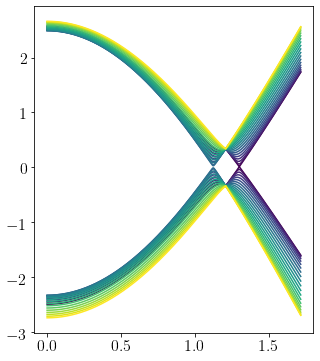

In [14]:
import matplotlib.colors as colors
import matplotlib.cm as cm

plt.figure(figsize=(5,6))

cmap = plt.get_cmap('viridis') 
cNorm  = colors.Normalize(vmin=kzs[0], vmax=kzs[-1])
scalarMap = cm.ScalarMappable(norm=cNorm, cmap=cmap)

for i in range(Ncuts):
    colorVal = scalarMap.to_rgba(kzs[i])
    plt.plot(klines[0],energy_cuts[i], color=colorVal)

#plt.ylim(-10,10)
#plt.xlim(0,2)

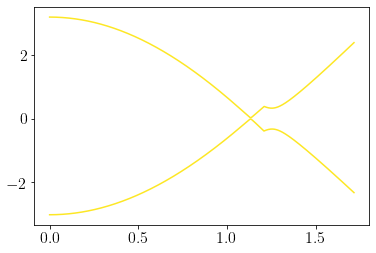

In [1406]:
i=7
plt.plot(klines[0],energy_cuts[i], color=colorVal)

#### Save to file for figures

In [15]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'graphite_bulk-band_cuts'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(kzs, fp)
pickle.dump(klines[0], fp)
pickle.dump(energy_cuts, fp)
#fp.close()

### (b) Slab geometry

### without strain

In [12]:
R = 10e8
Lz = 100

In [13]:
params = dict(R=R, Lz=Lz, mu=mu, gamma0=gamma0, gamma1=gamma1, gamma2=gamma2, 
              gamma3=gamma3, gamma4=gamma4)

In [14]:
a=1.0

Mx = 2*pi/(3*a)
My = 0.
    
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)

Ax = Kx
Ay = Ky*0.82

Bx = Kx*0.92
By = Ky*0.92

k_points = [(Ax,Ay), (Kx,Ky), (Bx,By)]
k_labels = ['$M\ldots$', '$K$', '$\ldots\Gamma$']

In [15]:
ks, evals, evecs = tools.compute_bands_2D(models.H_strain_rhombo_graphite, params, k_points)

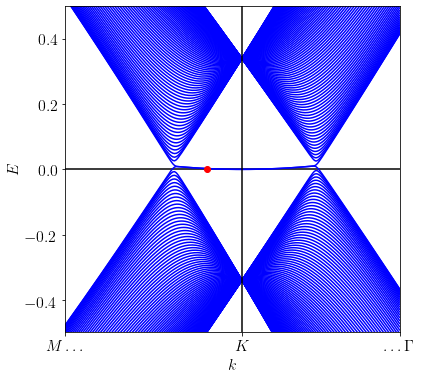

In [17]:
tools.plot_bands_2D(ks, evals, k_labels, ymin=-0.5, ymax=0.5, figsize=(6,6))
plt.plot(ks[80],0.0, c='red', marker='o')

In [19]:
i=80
print(evals[i,Lz-2:Lz+2])

[-0.15748364  0.0026155   0.00261551  0.16780945]


In [20]:
evecs_1 = evecs[i,:,Lz-1]
evecs_2 = evecs[i,:,Lz]

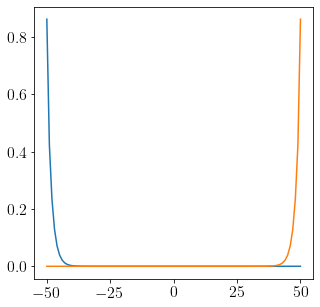

In [21]:
plt.figure(figsize=(5,5))

zs = np.linspace(-Lz/2, Lz/2, Lz)
densities1 = tools.density(evecs_1,2)
densities2 = tools.density(evecs_2,2)

plt.plot(zs, np.sqrt(densities1))
plt.plot(zs, np.sqrt(densities2))

In [249]:
# calculate spectral function
Nkx = 51
Nky = Nkx

Ef = -0.0

kx0 = 1.6
kx1 = 2.6
ky0 = 0.7
ky1 = 1.7

In [250]:
kxs = np.linspace(kx0,kx1,Nkx)
kys = np.linspace(ky0,ky1,Nky)
S = np.zeros((Nkx,Nky))

hamiltonian = partial(models.H_strain_rhombo_graphite, **params) 

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S[i,j] = tools.spectral_function_2D((kx,ky), hamiltonian, Ef)     

Text(0, 0.5, '$k_y$')

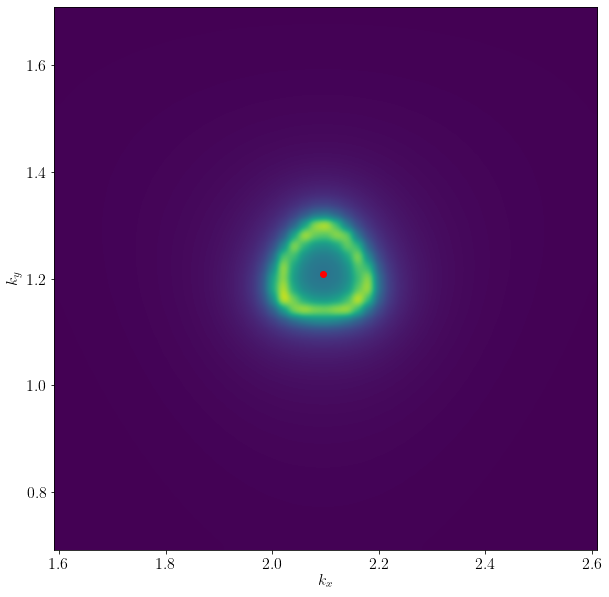

In [254]:
a=1.
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)

plt.figure(figsize=(10,10))
plt.imshow(S.transpose(), extent=(tools.imshow_extent(kxs,kys)), aspect=1, origin='lower', interpolation='gaussian')
plt.plot(Kx,Ky,'ro') 
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
#plt.colorbar()

## Strained system - Slab geometry

In [56]:
R1 = 400
Lz = 100

params = dict(R=R1, Lz=Lz, mu=mu, gamma0=gamma0, gamma1=gamma1, gamma2=gamma2, 
              gamma3=gamma3, gamma4=gamma4)

In [57]:
a=1.0

Mx = 2*pi/(3*a)
My = 0.
    
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)

Ax = Kx
Ay = Ky*0.82

Bx = Kx*0.92
By = Ky*0.92


k_points = [(Ax,Ay), (Kx,Ky), (Bx,By)]
k_labels = ['$M\ldots$', '$K$', '$\ldots\Gamma$']

In [58]:
ks1, evals1, evecs1 = tools.compute_bands_2D(models.H_strain_rhombo_graphite, params, k_points, Nk=100)

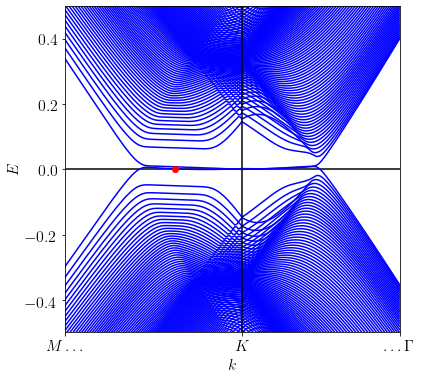

In [59]:
tools.plot_bands_2D(ks1, evals1, k_labels, ymin=-0.5, ymax=0.5, figsize=(6,6))
plt.plot(ks1[62],0.0, c='red', marker='o')

In [61]:
i=62
print(evals1[i,Lz-2:Lz+2])

[-0.04998678  0.00158704  0.00798933  0.06589457]


In [62]:
evecs_1 = evecs1[i,:,Lz-1]
evecs_2 = evecs1[i,:,Lz]

In [63]:
evecs_flat = evecs1[:,:,Lz-1:Lz+1]

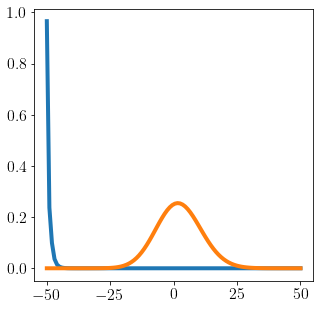

In [64]:
plt.figure(figsize=(5,5))

zs = np.linspace(-Lz/2, Lz/2, Lz)
densities1 = tools.density(evecs_1,2)
densities2 = tools.density(evecs_2,2)

#plt.xticks([])
#plt.yticks([])

plt.plot(zs, np.sqrt(densities1), lw=4)
plt.plot(zs, np.sqrt(densities2), lw=4)

#### Save to file for figures

In [45]:
params = dict(R1=R1, Lz=Lz, a=a)

In [46]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'graphite_LL_spectrum'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(ks1, fp)
pickle.dump(evals1, fp)
pickle.dump(evecs_flat, fp)
#fp.close()

### Spectral function

In [65]:
# calculate spectral function
Nkx = 25
Nky = Nkx

Ef = -0.0

kx0 = 1.7
kx1 = 2.5
ky0 = 0.85
ky1 = 1.65

In [66]:
kxs = np.linspace(kx0,kx1,Nkx)
kys = np.linspace(ky0,ky1,Nky)
S = np.zeros((Nkx,Nky))

hamiltonian = partial(models.H_strain_rhombo_graphite, **params) 

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S[i,j] = tools.spectral_function_2D((kx,ky), hamiltonian, Ef)     

Text(0, 0.5, '$k_y$')

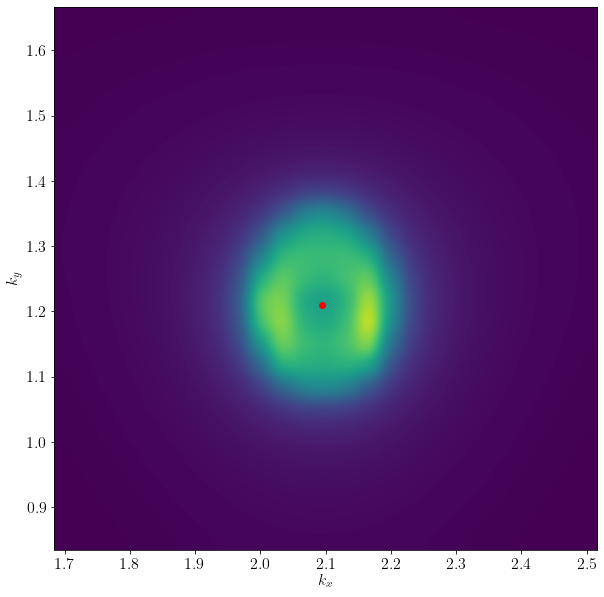

In [67]:
a=1.
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)

plt.figure(figsize=(10,10))
plt.imshow(S.transpose(), extent=(tools.imshow_extent(kxs,kys)), aspect=1, origin='lower', interpolation='gaussian')
plt.plot(Kx,Ky,'ro') 
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
#plt.colorbar()

## Analyzing shift behavior

In [24]:
Nk = 51

Lz = 500
R = 5000#*1e10

mu = 0.0
gamma0 = 3.2
gamma1 = 0.39/3
gamma2 = 0.0
gamma3 = 0.0
gamma4 = 0.0

kmax = 0.05

params = dict(R=R, Lz=Lz, mu=mu, gamma0=gamma0, gamma1=gamma1, gamma2=gamma2, 
              gamma3=gamma3, gamma4=gamma4)

In [25]:
a=1.0
  
Kx = 2*pi/(3*a)
Ky = 2*pi/(3*sqrt(3)*a)

#### along kx direction

In [26]:
kxs = np.linspace(Kx-kmax,Kx+kmax,Nk)

evalsx = np.zeros((Nk,2*Lz))
evecsx = np.zeros((Nk,2*Lz,2*Lz), dtype='complex')

for i,k in tqdm(list(enumerate(kxs))):
    evalsx[i,:], evecsx[i,:,:] = np.linalg.eigh(models.H_strain_rhombo_graphite(k, Ky, **params))

0.006916666666666477


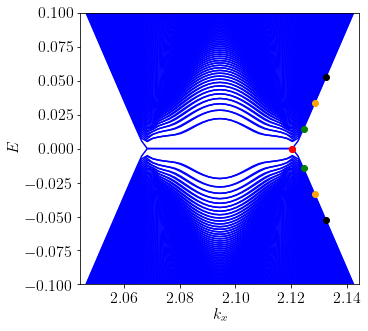

In [27]:
i1=38
i2=40
i3=42
i4=44

plt.figure(figsize=(5,5))
plt.plot(kxs,evalsx,'b-')
plt.plot(kxs[i1],evalsx[i1,Lz-1], c='red', marker='o')
plt.plot(kxs[i1],evalsx[i1,Lz], c='red', marker='o')
plt.plot(kxs[i2],evalsx[i2,Lz-1], c='green', marker='o')
plt.plot(kxs[i2],evalsx[i2,Lz], c='green', marker='o')
plt.plot(kxs[i3],evalsx[i3,Lz-1], c='orange', marker='o')
plt.plot(kxs[i3],evalsx[i3,Lz], c='orange', marker='o')
plt.plot(kxs[i4],evalsx[i4,Lz-1], c='black', marker='o')
plt.plot(kxs[i4],evalsx[i4,Lz], c='black', marker='o')

plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.1,0.1)
plt.xlim(Kx-kmax,Kx+kmax)
#plt.xlim(2.128,2.133)
#plt.ylim(0.031,0.054)

print(kxs[i3]-Kx-(2*gamma1/(3*gamma0)))

In [28]:
densitiesx_1 = np.zeros((Nk, Lz))
densitiesx_2 = np.zeros((Nk, Lz))

for i in range(Nk):
    densitiesx_1[i,:] = tools.density(evecsx[i,:,Lz-1],2)
    densitiesx_2[i,:] = tools.density(evecsx[i,:,Lz],2)

2.1183951023931953


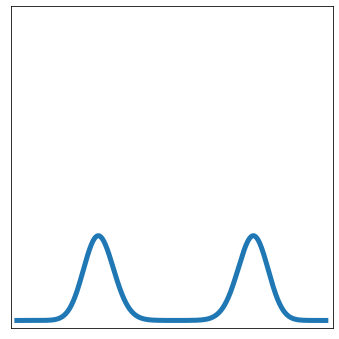

In [30]:
i=39
#i=37
#i=25
#i=13
#i=11

print(kxs[i])
plt.figure(figsize=(5,5))
plt.plot(np.sqrt((densitiesx_1[i,:] + densitiesx_2[i,:])/2),lw=5.0)
plt.xlabel('')
plt.ylabel('')
plt.ylim(-0.01,0.4)
plt.xlim(-10,Lz+10)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('figures/wavefunction_shifts_graphite/density_kx_4.pdf')

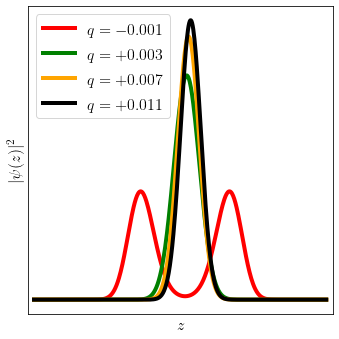

In [31]:
i1=38
i2=40
i3=42
i4=44

plt.figure(figsize=(5,5))
plt.plot(densitiesx_1[i1,:],lw=4.0, c='red', label='$q=-0.001$')
plt.plot(densitiesx_2[i1,:],lw=1.0, c='red')
plt.plot(densitiesx_1[i2,:],lw=4.0, c='green', label='$q=+0.003$')
plt.plot(densitiesx_2[i2,:],lw=1.0, c='green')
plt.plot(densitiesx_1[i3,:],lw=4.0, c='orange', label='$q=+0.007$')
plt.plot(densitiesx_2[i3,:],lw=1.0, c='orange')
plt.plot(densitiesx_1[i4,:],lw=4.0, c='black', label='$q=+0.011$')
plt.plot(densitiesx_2[i4,:],lw=1.0, c='black')
plt.ylabel('$|\psi(z)|^2$')
plt.xlabel('$z$')
#plt.ylim(-0.01,0.4)
plt.xlim(-10,Lz+10)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.legend()
#plt.savefig('figures/wavefunction_shifts_graphite/density_kx_4.pdf')

#### along ky direction

In [32]:
kmax = 0.06
kys = np.linspace(Ky-kmax,Ky+kmax,Nk)

evalsy = np.zeros((Nk,2*Lz))
evecsy = np.zeros((Nk,2*Lz,2*Lz), dtype='complex')

for i,k in tqdm(list(enumerate(kys))):
    evalsy[i,:], evecsy[i,:,:] = np.linalg.eigh(models.H_strain_rhombo_graphite(Kx, k, **params))

(1.149199576156145, 1.2691995761561452)

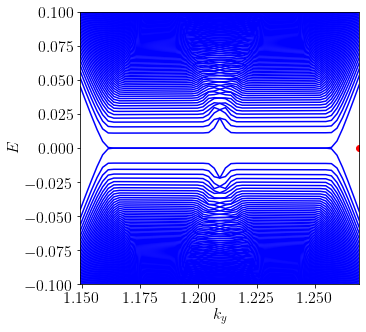

In [33]:
plt.figure(figsize=(5,5))
plt.plot(kys,evalsy,'b-')
plt.plot(kys[i],0.0, c='red', marker='o')
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.1,0.1)
plt.xlim(Ky-kmax,Ky+kmax)

In [34]:
densitiesy_1 = np.zeros((Nk, Lz))
densitiesy_2 = np.zeros((Nk, Lz))

for i in range(Nk):
    densitiesy_1[i,:] = tools.density(evecsy[i,:,Lz-1],2)
    densitiesy_2[i,:] = tools.density(evecsy[i,:,Lz],2)

1.2691995761561452


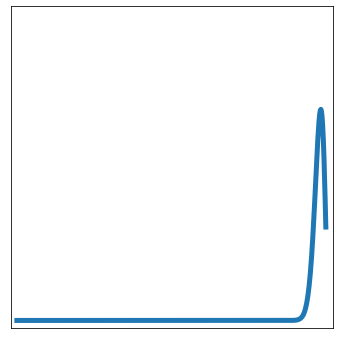

In [35]:
#i=42
#i=36
#i=31
#i=25
#i=19
#i=14
#i=8


print(kys[i])
plt.figure(figsize=(5,5))
plt.plot(np.sqrt((densitiesy_1[i,:] + densitiesy_2[i,:])/2),lw=5.0)
#plt.ylim(-0.01,0.53)
plt.xlabel('')
plt.ylabel('')
plt.ylim(-0.01,0.4)
plt.xlim(-10,Lz+10)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('figures/wavefunction_shifts_graphite/density_ky_6.pdf')